# 📦 01 — Data Cleaning
**E-Commerce Customer & Revenue Analytics Platform**

This notebook demonstrates the complete data cleaning pipeline:
- Load raw data and inspect quality
- Handle missing values, duplicates, invalid prices, negative quantities
- Feature engineering: Revenue, date parts, Customer Lifetime Revenue
- Save cleaned dataset to `data/processed/`

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# Generate raw data if it does not exist
raw_path = os.path.join('..', 'data', 'raw', 'ecommerce_data.csv')
if not os.path.exists(raw_path):
    from generate_data import generate_dataset
    df_raw = generate_dataset(10000)
    os.makedirs(os.path.dirname(raw_path), exist_ok=True)
    df_raw.to_csv(raw_path, index=False)
    print(f'Generated: {df_raw.shape}')
else:
    print(f'Raw dataset exists: {raw_path}')

Raw dataset exists: ..\data\raw\ecommerce_data.csv


## Step 1: Load & Inspect Raw Data

In [2]:
df_raw = pd.read_csv(raw_path, parse_dates=['InvoiceDate'], dtype={'CustomerID': str})
print(f'Shape: {df_raw.shape}')
print(f'\nColumn types:\n{df_raw.dtypes}')
df_raw.head(10)

Shape: (10300, 8)

Column types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID             object
Country                object
dtype: object


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,539559,20725,LUNCH BAG RED RETROSPOT,24,2023-12-06,1.40,10731,Netherlands
1,539979,85123A,WHITE HANGING HEART T-LIGHT HOLDER,15,2023-03-29,2.69,11204,United Kingdom
2,537675,23166,MEDIUM CERAMIC TOP STORAGE JAR,5,2023-05-27,1.48,10256,United Kingdom
3,539788,20719,WOODLAND CHARLOTTE BAG,18,2022-03-28,0.70,10806,United Kingdom
4,538013,23228,SPACESHIP LAMP,40,2023-01-12,2.66,10084,Switzerland
5,540779,22144,FINISH LINE ENAMEL MUG,20,2023-10-04,1.00,10274,United Kingdom
6,537666,22144,FINISH LINE ENAMEL MUG,3,2023-12-16,1.26,10365,United Kingdom
7,540357,21930,JUMBO STORAGE BAG SUKI,16,2023-11-02,2.40,11065,Sweden
8,539761,22111,SCOTTIE DOG HOT WATER BOTTLE,35,2022-03-04,4.79,10378,United Kingdom
9,537178,20727,LUNCH BAG BLACK SKULL,19,2022-10-05,1.46,11052,United Kingdom


In [3]:
print('=== Data Quality Summary ===')
print(f'Total rows      : {len(df_raw):,}')
print(f'Duplicates      : {df_raw.duplicated().sum():,}')
print(f'Missing values  :\n{df_raw.isnull().sum()}')
print(f'Neg quantities  : {(df_raw["Quantity"] < 0).sum():,}')
print(f'Invalid prices  : {(df_raw["UnitPrice"] <= 0).sum():,}')

=== Data Quality Summary ===
Total rows      : 10,300
Duplicates      : 300
Missing values  :
InvoiceNo        0
StockCode        0
Description    308
Quantity         0
InvoiceDate      0
UnitPrice        0
CustomerID     823
Country          0
dtype: int64
Neg quantities  : 407
Invalid prices  : 208


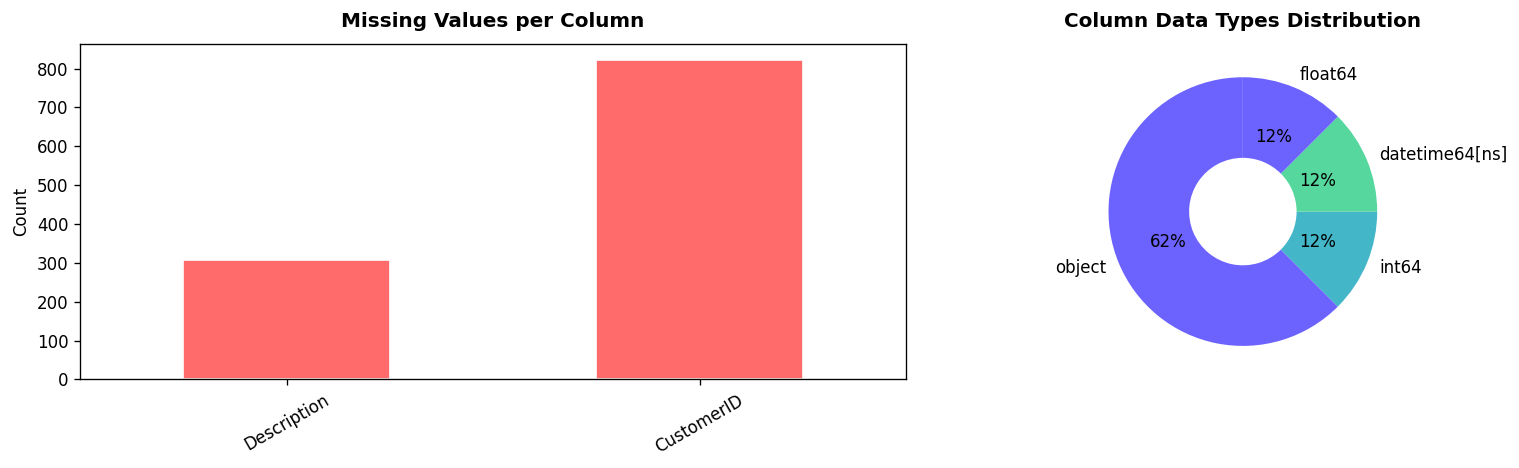

In [4]:
# Missing value heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor('white')

miss = df_raw.isnull().sum()
miss[miss > 0].plot(kind='bar', color='#FF6B6B', ax=axes[0], edgecolor='white')
axes[0].set_title('Missing Values per Column', fontweight='bold', pad=10)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

dtype_counts = df_raw.dtypes.astype(str).value_counts()
axes[1].pie(dtype_counts.values, labels=dtype_counts.index,
            autopct='%1.0f%%', colors=['#6C63FF', '#43B6C8', '#56D79E'],
            startangle=90, wedgeprops=dict(width=0.6))
axes[1].set_title('Column Data Types Distribution', fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

## Step 2: Run Full Cleaning Pipeline

In [5]:
import logging
logging.basicConfig(level=logging.INFO, format='%(message)s')

from data_cleaning import run_cleaning_pipeline
df_clean = run_cleaning_pipeline()
print(f'\nClean dataset shape: {df_clean.shape}')

Loading raw data from: D:\Ecommerce_Analytics_Platform\data\raw\ecommerce_data.csv
Raw shape: (10300, 8)
--- RAW Quality Report ---
  Shape          : (10300, 8)
  Null values    : 1131
  Duplicates     : 300
  Neg quantities : 407
  Invalid prices : 208
Removed 300 duplicate rows.
Filled 300 missing Descriptions with 'Unknown Product'.
Removed 800 rows with missing CustomerID.
Removed 183 rows with invalid UnitPrice (≤ 0).
Removed 376 rows with negative/zero Quantity.
Removed 186 cancelled invoice rows.
Engineering features...
Features created: Revenue, OrderYear, OrderMonth, OrderDay, OrderDayOfWeek, YearMonth
--- CLEANED Quality Report ---
  Shape          : (8455, 14)
  Null values    : 0
  Duplicates     : 0
  Neg quantities : 0
  Invalid prices : 0
Cleaned dataset saved → D:\Ecommerce_Analytics_Platform\data\processed\cleaned_data.csv
Building customer-level summary...
Customer summary shape: (1499, 9)
Customer summary saved → D:\Ecommerce_Analytics_Platform\data\processed\custom


Clean dataset shape: (8455, 14)


## Step 3: Before vs After Comparison

                    Before Cleaning  After Cleaning
Total Rows                    10300            8455
Duplicates                      300               0
Missing CustomerID              823               0
Negative Quantity               407               0
Invalid Price                   208               0


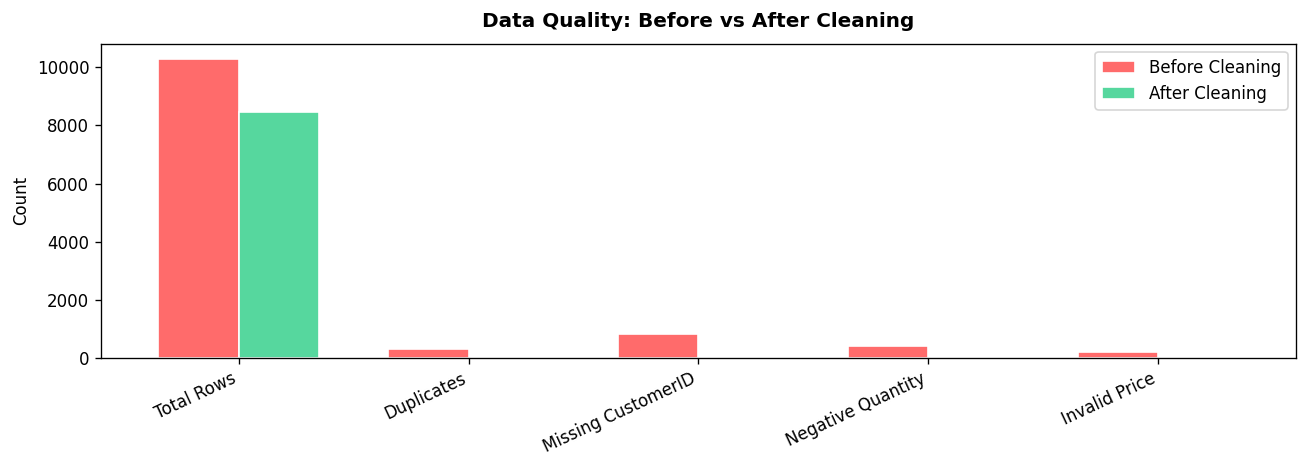

In [6]:
comparison = pd.DataFrame({
    'Before Cleaning': [
        df_raw.shape[0],
        int(df_raw.duplicated().sum()),
        int(df_raw['CustomerID'].isnull().sum()),
        int((df_raw['Quantity'] < 0).sum()),
        int((df_raw['UnitPrice'] <= 0).sum())
    ],
    'After Cleaning': [
        df_clean.shape[0], 0, 0, 0, 0
    ]
}, index=['Total Rows', 'Duplicates', 'Missing CustomerID',
          'Negative Quantity', 'Invalid Price'])

print(comparison)

comparison.plot(kind='bar', figsize=(11, 4),
                color=['#FF6B6B', '#56D79E'], edgecolor='white', width=0.7)
plt.title('Data Quality: Before vs After Cleaning', fontweight='bold', pad=10)
plt.xticks(rotation=25, ha='right')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## Step 4: Engineered Features

In [7]:
new_cols = [c for c in df_clean.columns if c not in df_raw.columns]
print('Newly engineered columns:', new_cols)
print(f'\nRevenue stats:\n{df_clean["Revenue"].describe().round(2)}')
df_clean[['InvoiceDate', 'Revenue', 'OrderYear', 'OrderMonth', 'OrderDay', 'YearMonth']].head(10)

Newly engineered columns: ['Revenue', 'OrderYear', 'OrderMonth', 'OrderDay', 'OrderDayOfWeek', 'YearMonth']

Revenue stats:
count    8455.00
mean       70.82
std        98.38
min         0.46
25%        20.71
50%        41.85
75%        80.08
max       991.27
Name: Revenue, dtype: float64


,InvoiceDate,Revenue,OrderYear,OrderMonth,OrderDay,YearMonth
0,2023-12-06,33.60,2023,12,6,2023-12
1,2023-03-29,40.35,2023,3,29,2023-03
2,2023-05-27,7.40,2023,5,27,2023-05
3,2022-03-28,12.60,2022,3,28,2022-03
4,2023-01-12,106.40,2023,1,12,2023-01
5,2023-10-04,20.00,2023,10,4,2023-10
6,2023-12-16,3.78,2023,12,16,2023-12
7,2023-11-02,38.40,2023,11,2,2023-11
8,2022-03-04,167.65,2022,3,4,2022-03
9,2022-10-05,27.74,2022,10,5,2022-10


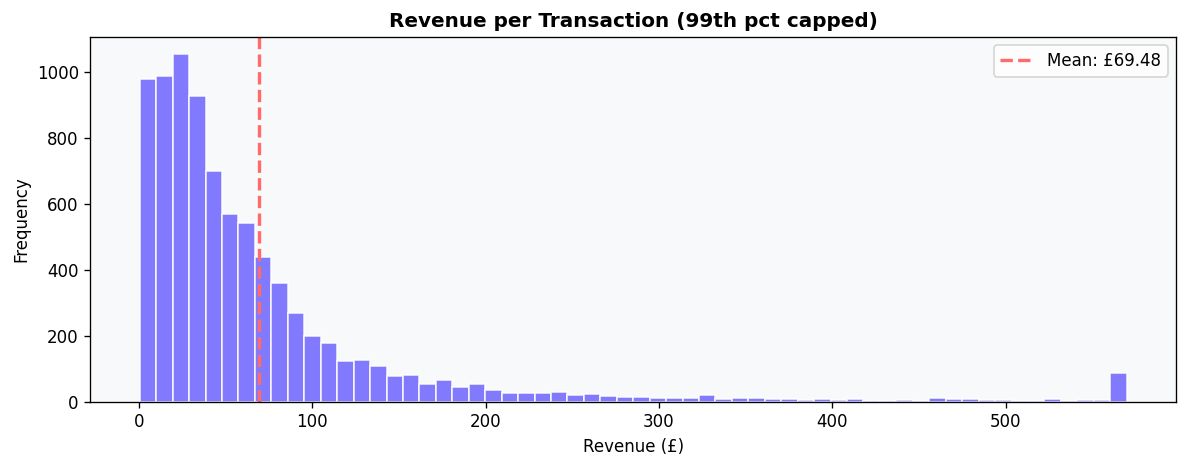

In [8]:
# Revenue distribution quick view
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f8f9fa')
capped = df_clean['Revenue'].clip(upper=df_clean['Revenue'].quantile(0.99))
ax.hist(capped, bins=60, color='#6C63FF', edgecolor='white', alpha=0.85)
ax.axvline(capped.mean(), color='#FF6B6B', linestyle='--', linewidth=2,
           label=f'Mean: £{capped.mean():.2f}')
ax.set_title('Revenue per Transaction (99th pct capped)', fontweight='bold')
ax.set_xlabel('Revenue (£)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

## ✅ Summary

| Step | Result |
|------|---------|
| Duplicates removed | ✓ |
| Missing CustomerIDs dropped | ✓ |
| Missing Descriptions filled | ✓ |
| Negative quantities removed | ✓ |
| Invalid prices removed | ✓ |
| Cancelled invoices removed | ✓ |
| Features engineered | Revenue, OrderYear, OrderMonth, OrderDay, YearMonth |

**Next**: `02_exploratory_analysis.ipynb`